Starting PINN training on cpu...
Epoch [1/12] | Loss: 1.1181 | LR: 0.001000
Epoch [2/12] | Loss: 1.1009 | LR: 0.001000
Epoch [3/12] | Loss: 1.1001 | LR: 0.001000
Epoch [4/12] | Loss: 1.0993 | LR: 0.001000
Epoch [5/12] | Loss: 1.0990 | LR: 0.001000
Epoch [6/12] | Loss: 1.0981 | LR: 0.001000
Epoch [7/12] | Loss: 1.0989 | LR: 0.001000
Epoch [8/12] | Loss: 1.0968 | LR: 0.001000
Epoch [9/12] | Loss: 1.0985 | LR: 0.001000
Epoch [10/12] | Loss: 1.0976 | LR: 0.001000
Epoch [11/12] | Loss: 1.0991 | LR: 0.000500
Epoch [12/12] | Loss: 1.0960 | LR: 0.000500


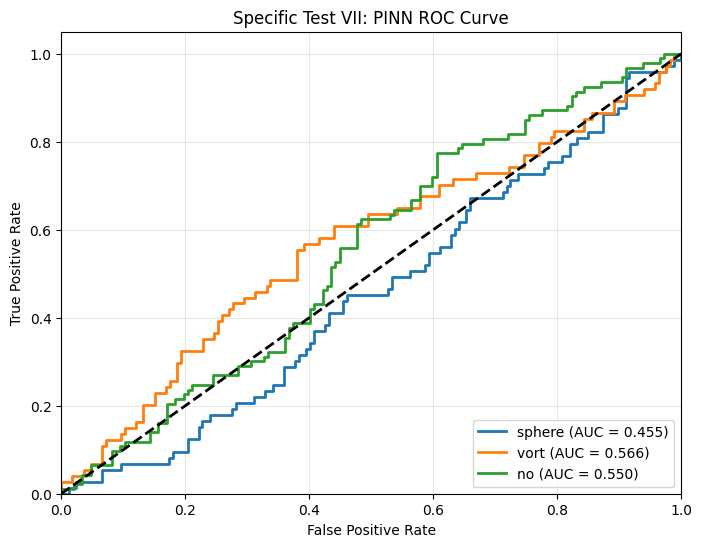

Model weights saved to 'Specific_Test_VII_PINN.pth'


In [6]:
import os
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# 1. Dataset Configuration

class LensingDataset(Dataset):
    def __init__(self, data_dir, limit_per_class=800):
        self.filepaths = []
        self.labels = []
        
        classes = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d)) and not d.startswith('.')]
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
        
        for cls_name, idx in self.class_to_idx.items():
            files = glob.glob(os.path.join(data_dir, cls_name, '*.npy'))[:limit_per_class]
            self.filepaths.extend(files)
            self.labels.extend([idx] * len(files))

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        img = np.load(self.filepaths[idx])
        if len(img.shape) == 2:
            img = np.expand_dims(img, axis=0)
            
        tensor_img = torch.tensor(img, dtype=torch.float32)
        
        # Standard Min-Max Normalization as required by the prompt
        t_min, t_max = tensor_img.min(), tensor_img.max()
        if t_max > t_min:
            tensor_img = (tensor_img - t_min) / (t_max - t_min)
            
        return tensor_img, torch.tensor(self.labels[idx], dtype=torch.long)

# 2. PINN Architecture

class PINNClassifier(nn.Module):
    def __init__(self, num_classes):
        super(PINNClassifier, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4))
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 4 * 4, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

# 3. Physics-Informed Loss Function

class GravitationalLensingLoss(nn.Module):
    def __init__(self, physics_weight=0.1):
        super(GravitationalLensingLoss, self).__init__()
        self.ce_loss = nn.CrossEntropyLoss()
        self.physics_weight = physics_weight

    def forward(self, predictions, targets, inputs):
        data_loss = self.ce_loss(predictions, targets)
        
        # Physics Constraint: Smoothness of the macroscopic lens model
        # Approximated via spatial gradients (Total Variation) of the image
        dx = torch.abs(inputs[:, :, :, :-1] - inputs[:, :, :, 1:])
        dy = torch.abs(inputs[:, :, :-1, :] - inputs[:, :, 1:, :])
        smoothness_penalty = torch.mean(dx) + torch.mean(dy)
        
        probs = torch.softmax(predictions, dim=1)
        # Assuming class 0 is 'no substructure' (smooth lens)
        physics_loss = torch.mean(probs[:, 0] * smoothness_penalty)
        
        return data_loss + (self.physics_weight * physics_loss)

# 4. Training Pipeline

def main():
    data_dir = "dataset_extraido/dataset/train"
    dataset = LensingDataset(data_dir, limit_per_class=800)
    
    train_size = int(0.9 * len(dataset))
    test_size = len(dataset) - train_size
    train_data, test_data = random_split(dataset, [train_size, test_size])
    
    train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_data, batch_size=32, shuffle=False)
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = PINNClassifier(num_classes=len(dataset.class_to_idx)).to(device)
    
    criterion = GravitationalLensingLoss(physics_weight=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
    
    epochs = 12
    print(f"Starting PINN training on {device}...")
    
    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0.0
        
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            
            outputs = model(inputs)
            loss = criterion(outputs, targets, inputs)
            
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            
        avg_loss = epoch_loss / len(train_loader)
        scheduler.step(avg_loss)
        print(f"Epoch [{epoch}/{epochs}] | Loss: {avg_loss:.4f} | LR: {optimizer.param_groups[0]['lr']:.6f}")

    # 5. Evaluation & ROC

    model.eval()
    all_targets, all_probs = [], []
    
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            
            all_targets.extend(targets.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            
    all_targets = np.array(all_targets)
    all_probs = np.array(all_probs)
    classes_list = list(dataset.class_to_idx.keys())
    binarized_targets = label_binarize(all_targets, classes=list(dataset.class_to_idx.values()))
    
    plt.figure(figsize=(8, 6))
    for i in range(len(classes_list)):
        fpr, tpr, _ = roc_curve(binarized_targets[:, i], all_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{classes_list[i]} (AUC = {roc_auc:.3f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Specific Test VII: PINN ROC Curve')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

    torch.save(model.state_dict(), "Specific_Test_VII_PINN.pth")
    print("Model weights saved to 'Specific_Test_VII_PINN.pth'")

if __name__ == '__main__':
    main()